In [ ]:
import tensorflow as tf

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU detected: {gpus[0].name}')
else:
    print('No GPU found')

TensorFlow version: 2.19.0
GPU detected: /physical_device:GPU:0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
shutil.copytree('/content/drive/MyDrive/Animals and Plants Dataset/train', '/content/train')
DATA_DIR = '/content/train'
print('Done copying')

Done copying


In [ ]:
import os
# Lists everything in the root of your Drive
print(os.listdir('/content/drive/MyDrive'))

['Untitled document (16).gdoc', 'Untitled presentation.gslides', 'Report.gdoc', 'Untitled document (15).gdoc', 'ttu-adho-pgs - Jan 7, 2023.pdf', 'Untitled document (14).gdoc', 'Untitled spreadsheet (3).gsheet', 'j.robert oppenheimer.gdoc', 'Cambodia Tourist Attractions.gdoc', 'Cambodian Culture.gdoc', 'AI Public speaking.gdoc', 'ICT Peer-Review (Responses).gsheet', 'Sources.gdoc', 'The Last Dance.gdoc', 'VITHYEA’s FAN FIC:.gdoc', "Copy of LA ROUGE's TICKET ONLINE ORDERING SERVICE (for Outsiders).gform", "LA ROUGE's TICKET ONLINE ORDERING SERVICE (for GGAS Students).gform", 'Untitled document (13).gdoc', "UNIVERSITIES'..gdoc", 'Schedule.gsheet', 'Untitled spreadsheet (2).gsheet', 'Classroom', 'ASPC Newsletter Sample (350 word max).gdoc', 'ITEC101 Lecture', 'Offer_Sovithyea_Prach (1).pdf', 'Offer_Sovithyea_Prach.pdf', 'ICT Peer-Review.gform', 'ASPC Invoice and ABA Transactions.gdoc', 'ASPC Expenses.gsheet', 'Colab Notebooks', 'Do you have a driving license? .gform', "Euphoria's Pre-Order

In [ ]:
DATA_DIR = '/content/drive/MyDrive/Animals and Plants Dataset/train'
print(os.listdir(DATA_DIR))

['Mammalia', 'Mollusca', 'Aves', 'Reptilia', 'Animalia', 'Fungi', 'Arachnida', 'Plantae', 'Insecta', 'Amphibia']


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# CONFIG
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS_FE = 10 # Feature extraction epochs
EPOCHS_FT = 10 # Fine-tuning epochs
NUM_CLASSES = 10
SEED = 42

print('Config ready')

Config ready


In [ ]:
# Training generator: with augmentation
train_datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
)

val_datagen = ImageDataGenerator(
    validation_split=0.2,
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f'\nClasses ({len(CLASS_NAMES)}): {CLASS_NAMES}')
print(f'Training samples  : {train_gen.samples}')
print(f'Validation samples: {val_gen.samples}')

Found 8008 images belonging to 10 classes.
Found 2000 images belonging to 10 classes.

Classes (10): ['Amphibia', 'Animalia', 'Arachnida', 'Aves', 'Fungi', 'Insecta', 'Mammalia', 'Mollusca', 'Plantae', 'Reptilia']
Training samples  : 8008
Validation samples: 2000


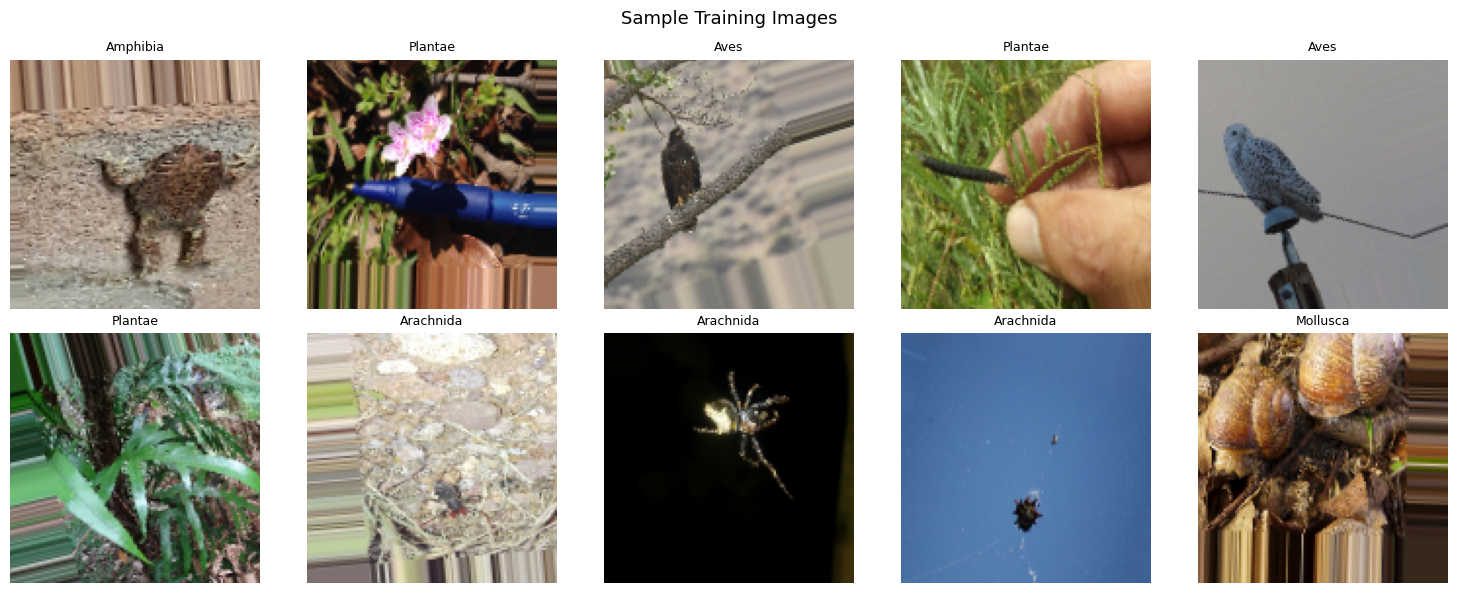

In [ ]:
images, labels = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images', fontsize=13)
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].astype('uint8'))
    ax.set_title(CLASS_NAMES[np.argmax(labels[i])], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def build_model(trainable_base=False, unfreeze_layers=0):
    base = EfficientNetB0(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )

    base.trainable = False

    if trainable_base and unfreeze_layers > 0:
        base.trainable = True
        for layer in base.layers[:-unfreeze_layers]:
            layer.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    lr = 1e-3 if not trainable_base else 1e-5
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f'Trainable parameters: {trainable_params:,}')
    return model, base

print('Model builder ready')

Model builder ready


In [ ]:
def get_callbacks(name):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'/content/best_{name}.keras',
            monitor='val_accuracy', save_best_only=True, verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
        ),
    ]

print('Callbacks ready')

Callbacks ready


In [ ]:
print('APPROACH A: FEATURE EXTRACTION')
print('Base model fully frozen - only head trains')

model_fe, _ = build_model(trainable_base=False)

start_fe = time.time()
history_fe = model_fe.fit(
    train_gen,
    epochs=EPOCHS_FE,
    validation_data=val_gen,
    callbacks=get_callbacks('feature_extraction')
)
time_fe = time.time() - start_fe

val_gen.reset()
_, acc_fe = model_fe.evaluate(val_gen, verbose=0)
print(f'\n Feature Extraction - Val Accuracy: {acc_fe*100:.2f}% | Time: {time_fe:.0f}s')

APPROACH A: FEATURE EXTRACTION
Base model fully frozen - only head trains
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Trainable parameters: 330,506
Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 221s 756ms/step - accuracy: 0.5177 - loss: 1.4400 - val_accuracy: 0.6880 - val_loss: 0.9635 - learning_rate: 0.0010
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 138s 550ms/step - accuracy: 0.5982 - loss: 1.1835 - val_accuracy: 0.6965 - val_loss: 0.9166 - learning_rate: 0.0010
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 133s 531ms/step - accuracy: 0.6205 - loss: 1.1002 - val_accuracy: 0.6965 - val_loss: 0.9103 - learning_rate: 0.0010
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 135s 538ms/step - accuracy: 0.6401 - loss: 1.0513 - val_accuracy: 0.6980 - val_loss: 0.8925 - learning_rate: 0.0010
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 132s 527ms/step - accuracy: 0.6582 - loss: 0.9953 - val_accuracy: 0.7020 - val_loss: 0.8815 - learning_rate: 0.0010
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 132s 526ms/step - accurac

In [ ]:
print('APPROACH B: FINE-TUNING')
print('Top 20 base layers unfrozen, LR = 1e-5')

model_ft, base_ft = build_model(trainable_base=True, unfreeze_layers=20)

frozen = sum(1 for l in base_ft.layers if not l.trainable)
unfrozen = sum(1 for l in base_ft.layers if l.trainable)
print(f'Base model: {unfrozen} unfrozen layers, {frozen} frozen layers')

start_ft = time.time()
history_ft = model_ft.fit(
    train_gen,
    epochs=EPOCHS_FT,
    validation_data=val_gen,
    callbacks=get_callbacks('fine_tuning')
)
time_ft = time.time() - start_ft

val_gen.reset()
_, acc_ft = model_ft.evaluate(val_gen, verbose=0)
print(f'\n Fine-Tuning - Val Accuracy: {acc_ft*100:.2f}% | Time: {time_ft:.0f}s')

APPROACH B: FINE-TUNING
Top 20 base layers unfrozen, LR = 1e-5
Trainable parameters: 1,681,466
Base model: 20 unfrozen layers, 218 frozen layers
Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 185s 631ms/step - accuracy: 0.1289 - loss: 2.3681 - val_accuracy: 0.2085 - val_loss: 2.1985 - learning_rate: 1.0000e-05
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 134s 533ms/step - accuracy: 0.2127 - loss: 2.1870 - val_accuracy: 0.3405 - val_loss: 2.0347 - learning_rate: 1.0000e-05
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 137s 546ms/step - accuracy: 0.3052 - loss: 2.0351 - val_accuracy: 0.4440 - val_loss: 1.8724 - learning_rate: 1.0000e-05
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 138s 550ms/step - accuracy: 0.3699 - loss: 1.9068 - val_accuracy: 0.5105 - val_loss: 1.7193 - learning_rate: 1.0000e-05
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 135s 538ms/step - accuracy: 0.4155 - loss: 1.7832 - val_accuracy: 0.5615 - val_loss: 1.5816 - learning_rate: 1.0000e-05
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 139s 552ms/step

In [ ]:
# Continue fine-tuning for more epochs
start_ft2 = time.time()
history_ft2 = model_ft.fit(
    train_gen,
    epochs=20, # run for more epochs
    initial_epoch=10, # continues from epoch 10
    validation_data=val_gen,
    callbacks=get_callbacks('fine_tuning')
)
time_ft2 = time.time() - start_ft2
time_ft_total = time_ft + time_ft2

val_gen.reset()
_, acc_ft = model_ft.evaluate(val_gen, verbose=0)
print(f'\n Fine-Tuning - Val Accuracy: {acc_ft*100:.2f}% | Total Time: {time_ft_total:.0f}s')

Epoch 11/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 141s 561ms/step - accuracy: 0.5380 - loss: 1.4063 - val_accuracy: 0.6485 - val_loss: 1.1476 - learning_rate: 1.0000e-05
Epoch 12/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 136s 542ms/step - accuracy: 0.5405 - loss: 1.3818 - val_accuracy: 0.6585 - val_loss: 1.1147 - learning_rate: 1.0000e-05
Epoch 13/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 135s 537ms/step - accuracy: 0.5543 - loss: 1.3389 - val_accuracy: 0.6625 - val_loss: 1.0894 - learning_rate: 1.0000e-05
Epoch 14/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 131s 521ms/step - accuracy: 0.5673 - loss: 1.3163 - val_accuracy: 0.6680 - val_loss: 1.0689 - learning_rate: 1.0000e-05
Epoch 15/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 130s 519ms/step - accuracy: 0.5716 - loss: 1.2907 - val_accuracy: 0.6735 - val_loss: 1.0469 - learning_rate: 1.0000e-05
Epoch 16/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 130s 518ms/step - accuracy: 0.5742 - loss: 1.2659 - val_accuracy: 0.6730 - val_loss: 1.0352 - learning_rate: 1.0000e-05
Epoch 17/20
251/251 ━━━━━━━━━━━━━━

In [ ]:
start_ft3 = time.time()
history_ft3 = model_ft.fit(
    train_gen,
    epochs=30,
    initial_epoch=20,
    validation_data=val_gen,
    callbacks=get_callbacks('fine_tuning')
)
time_ft3 = time.time() - start_ft3
time_ft_total = time_ft + time_ft2 + time_ft3

val_gen.reset()
_, acc_ft = model_ft.evaluate(val_gen, verbose=0)
print(f'\n Fine-Tuning — Val Accuracy: {acc_ft*100:.2f}% | Total Time: {time_ft_total:.0f}s')

In [ ]:
# Increase LR slightly and continue
import tensorflow as tf
model_ft.optimizer.learning_rate.assign(5e-5)

start_ft4 = time.time()
history_ft4 = model_ft.fit(
    train_gen,
    epochs=40,
    initial_epoch=30,
    validation_data=val_gen,
    callbacks=get_callbacks('fine_tuning')
)
time_ft4 = time.time() - start_ft4
time_ft_total = time_ft + time_ft2 + time_ft3 + time_ft4

val_gen.reset()
_, acc_ft = model_ft.evaluate(val_gen, verbose=0)
print(f'\n Fine-Tuning — Val Accuracy: {acc_ft*100:.2f}% | Total Time: {time_ft_total:.0f}s')

In [ ]:
# Results comparison
print(f'{"Method":<25} {"Val Accuracy":>14} {"Training Time":>15}')
print('-'*55)
print(f'{"Feature Extraction":<25} {acc_fe*100:>13.2f}% {time_fe:>13.0f}s')
print(f'{"Fine-Tuning":<25} {acc_ft*100:>13.2f}% {time_ft_total:>13.0f}s')

In [ ]:
for label, model in [('Feature Extraction', model_fe), ('Fine-Tuning', model_ft)]:
    val_gen.reset()
    preds = model.predict(val_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_gen.classes
    print(f'\n Classification Report: {label}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Extraction vs Fine-Tuning - Training Curves', fontsize=14, fontweight='bold')

for col, (hist, label, color) in enumerate([
    (history_fe, 'Feature Extraction', 'steelblue'),
    (history_ft3, 'Fine-Tuning', 'darkorange'),
]):
    axes[0][col].plot(hist.history['accuracy'], label='Train', color=color)
    axes[0][col].plot(hist.history['val_accuracy'], label='Validation', color=color, linestyle='--')
    axes[0][col].set_title(f'{label} - Accuracy')
    axes[0][col].set_xlabel('Epoch'); axes[0][col].set_ylabel('Accuracy')
    axes[0][col].legend(); axes[0][col].grid(True, alpha=0.3)

    axes[1][col].plot(hist.history['loss'], label='Train', color=color)
    axes[1][col].plot(hist.history['val_loss'], label='Validation', color=color, linestyle='--')
    axes[1][col].set_title(f'{label} - Loss')
    axes[1][col].set_xlabel('Epoch'); axes[1][col].set_ylabel('Loss')
    axes[1][col].legend(); axes[1][col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
val_gen.reset()
preds = model_ft.predict(val_gen, verbose=0)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Fine-Tuning', fontsize=13)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()